---
title: Exploración de datos y análisis complementarios
description: Tres análisis complementarios al artículo principal — contexto histórico del calentamiento global GMST, sensibilidad al factor de amplificación regional (FAR) y tiempo de emergencia del calentamiento en Montería, Córdoba
authors:
  - name: Mauricio Romero
    orcid: 0000-0003-3282-0372
---

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scr-ungrd/cuadernos-reproducibles-crc001/blob/main/notebooks/data-screening-visualization.ipynb)


Este cuaderno presenta tres análisis de datos que complementan los resultados del artículo principal, profundizando en aspectos metodológicos y de contexto que enriquecen la interpretación de las proyecciones climáticas para Montería, Córdoba:

1. **Contexto histórico de GMST (1880–2024):** ubica las proyecciones dentro de la tendencia de calentamiento observada desde la era preindustrial.
2. **Sensibilidad al factor de amplificación regional (FAR):** cuantifica cuánto influye la incertidumbre del FAR sobre la temperatura proyectada en 2074.
3. **Tiempo de emergencia del calentamiento:** determina en qué año el calentamiento proyectado supera de manera robusta la variabilidad climática natural para cada escenario RCP.

In [1]:
%pip install climada matplotlib seaborn pandas numpy scipy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from climada.hazard.tc_clim_change import get_gmst_info

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})
sns.set_palette("colorblind")

# Parámetros del proyecto — idénticos a article.ipynb
LAT_MON, LON_MON  = 8.7479, -75.8814
T_BASE_MON        = 27.5   # °C, climatología 1991-2020 (IDEAM)
SIGMA_INTERANUAL  = 0.8    # °C
FAR_NSA           = 1.05   # factor amplificación regional Caribe colombiano
FAR_SIGMA         = 0.10
ANIO_INICIO       = 2024
ANIO_FIN          = 2074
N_ENSAMBLE        = 500
RCP_LIST          = ['2.6', '4.5', '6.0', '8.5']
RCP_COLORS        = {'2.6': '#1f77b4', '4.5': '#2ca02c', '6.0': '#ff7f0e', '8.5': '#d62728'}
RCP_LABELS        = {
    '2.6': 'RCP 2.6 (mitigación fuerte)',
    '4.5': 'RCP 4.5 (mitigación intermedia)',
    '6.0': 'RCP 6.0 (mitigación limitada)',
    '8.5': 'RCP 8.5 (altas emisiones)',
}
ANIO_REF_INI, ANIO_REF_FIN = 1991, 2020
np.random.seed(42)

print("Librerías cargadas correctamente.")
# ── Parámetros (espejo de article.ipynb para uso autónomo en Colab) ────────
LAT_MON, LON_MON = 8.7479, -75.8814
T_BASE_MON        = 27.5          # °C, climatología 1991-2020
SIGMA_INTERANUAL  = 0.8           # °C
FAR_NSA           = 1.05
FAR_SIGMA         = 0.10
ANIO_INICIO       = 2024
ANIO_FIN          = 2074
N_ENSAMBLE        = 500
ANIO_REF_INI      = 1991
ANIO_REF_FIN      = 2020
RCP_LIST          = ['2.6', '4.5', '6.0', '8.5']
RCP_LABELS        = {
    '2.6': 'RCP 2.6 (mitigación fuerte)',
    '4.5': 'RCP 4.5 (mitigación intermedia)',
    '6.0': 'RCP 6.0 (mitigación limitada)',
    '8.5': 'RCP 8.5 (altas emisiones)',
}
RCP_COLORS = {'2.6': '#1f77b4', '4.5': '#2ca02c', '6.0': '#ff7f0e', '8.5': '#d62728'}

np.random.seed(42)
print("Parámetros cargados.")


Note: you may need to restart the kernel to use updated packages.


Librerías cargadas correctamente.
Parámetros cargados.


In [2]:
# Carga de GMST desde CLIMADA y construcción del ensamble de proyecciones
gmst_info  = get_gmst_info()
years_gmst = np.arange(gmst_info['gmst_start_year'], gmst_info['gmst_end_year'] + 1)
df_gmst    = pd.DataFrame(
    gmst_info['gmst_data'].T,
    index=years_gmst,
    columns=[f"RCP {r}" for r in gmst_info['rcps']],
)
df_gmst.index.name = 'año'

ref_mean = df_gmst.loc[ANIO_REF_INI:ANIO_REF_FIN].mean()
df_anom  = df_gmst - ref_mean

anios_proy = np.arange(ANIO_INICIO, ANIO_FIN + 1)
n_anios    = len(anios_proy)
proyecciones = {}
for rcp in RCP_LIST:
    delta = df_anom.loc[anios_proy[0]:anios_proy[-1], f"RCP {rcp}"].values
    far_k = np.clip(np.random.normal(FAR_NSA, FAR_SIGMA, N_ENSAMBLE).reshape(-1, 1), 0.7, 1.4)
    eps   = np.random.normal(0, SIGMA_INTERANUAL, (N_ENSAMBLE, n_anios))
    proyecciones[rcp] = T_BASE_MON + far_k * delta[None, :] + eps

print("Ensamble de proyecciones generado:", {k: v.shape for k, v in proyecciones.items()})

Ensamble de proyecciones generado: {'2.6': (500, 51), '4.5': (500, 51), '6.0': (500, 51), '8.5': (500, 51)}


## Análisis 1: Contexto histórico del calentamiento global (GMST 1880–2100)

Las proyecciones del artículo principal se construyen sobre anomalías GMST respecto a 1991–2020. Este análisis sitúa esas anomalías dentro del registro completo de temperatura media superficial global desde 1880, permitiendo apreciar el ritmo y la magnitud del calentamiento observado en relación con las metas del Acuerdo de París (+1.5 °C y +2.0 °C sobre el nivel preindustrial).

El panel inferior muestra la **tasa de calentamiento en ventana móvil de 20 años**, lo que revela la aceleración del calentamiento desde mediados del siglo XX.

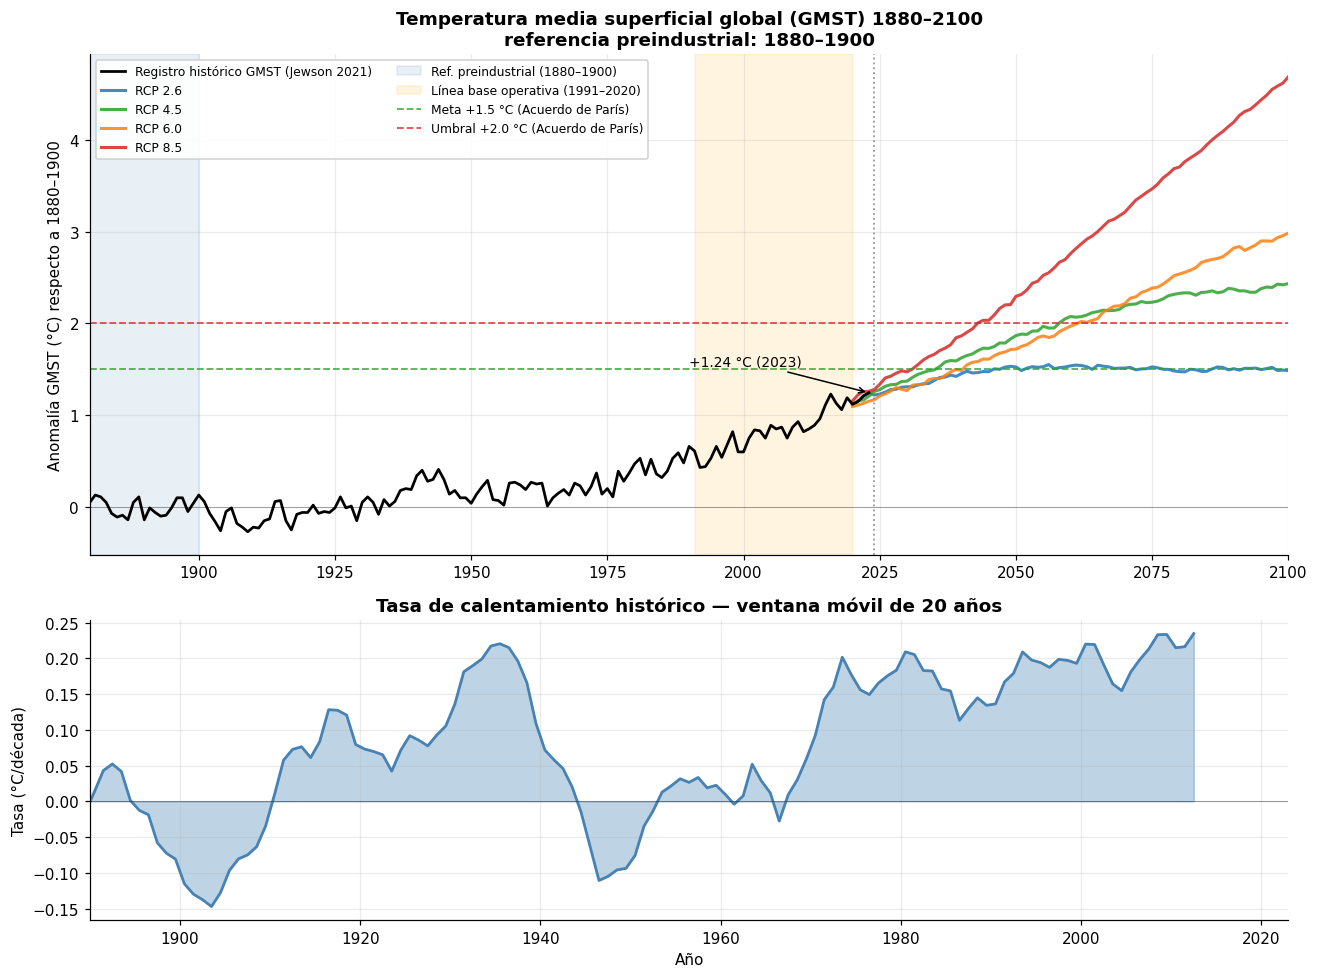

Calentamiento observado al 2023: +1.24 °C sobre nivel preindustrial (1880–1900).


In [3]:
# Anomalía respecto al período preindustrial disponible en CLIMADA (1880–1900)
preindustrial_mean  = df_gmst.loc[1880:1900].mean()
df_preindustrial_anom = df_gmst - preindustrial_mean

years_hist   = years_gmst[years_gmst <= 2023]
years_future = years_gmst[(years_gmst >= 2020) & (years_gmst <= 2100)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9),
                                gridspec_kw={'height_ratios': [2, 1.2]},
                                sharex=False)

# ── Panel superior: trayectoria GMST completa ──────────────────────────────
ax1.plot(years_hist, df_preindustrial_anom.loc[years_hist, 'RCP 2.6'],
         color='black', lw=1.8, label='Registro histórico GMST (Jewson 2021)', zorder=5)

for rcp in RCP_LIST:
    ax1.plot(years_future, df_preindustrial_anom.loc[years_future, f'RCP {rcp}'],
             color=RCP_COLORS[rcp], lw=2.0, label=f'RCP {rcp}', alpha=0.85)

ax1.axvspan(1880, 1900,            alpha=0.12, color='steelblue', label='Ref. preindustrial (1880–1900)')
ax1.axvspan(ANIO_REF_INI, ANIO_REF_FIN, alpha=0.12, color='orange',    label='Línea base operativa (1991–2020)')
ax1.axvline(ANIO_INICIO, color='gray', ls=':', lw=1.2, alpha=0.8)
ax1.axhline(0,   color='black', lw=0.6, alpha=0.35)
ax1.axhline(1.5, color='#2ca02c', ls='--', lw=1.2, alpha=0.8, label='Meta +1.5 °C (Acuerdo de París)')
ax1.axhline(2.0, color='#d62728', ls='--', lw=1.2, alpha=0.8, label='Umbral +2.0 °C (Acuerdo de París)')

# Anotación del valor de calentamiento actual (~2024)
val_2023 = df_preindustrial_anom.loc[2023, 'RCP 2.6']
ax1.annotate(f'+{val_2023:.2f} °C (2023)', xy=(2023, val_2023),
             xytext=(1990, val_2023 + 0.3),
             arrowprops=dict(arrowstyle='->', color='black', lw=1),
             fontsize=9)

ax1.set_ylabel('Anomalía GMST (°C) respecto a 1880–1900')
ax1.set_title('Temperatura media superficial global (GMST) 1880–2100\n'
              'referencia preindustrial: 1880–1900',
              fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.9)
ax1.set_xlim(1880, 2100)

# ── Panel inferior: tasa de calentamiento (ventana móvil 20 años) ──────────
hist_vals = df_preindustrial_anom.loc[years_hist, 'RCP 2.6'].values
WINDOW = 20
slopes, centers = [], []
for i in range(len(years_hist) - WINDOW):
    y = years_hist[i:i + WINDOW].astype(float)
    v = hist_vals[i:i + WINDOW]
    slope, *_ = stats.linregress(y, v)
    slopes.append(slope * 10)   # °C/década
    centers.append(y.mean())

ax2.fill_between(centers, slopes, alpha=0.35, color='steelblue')
ax2.plot(centers, slopes, color='steelblue', lw=1.8)
ax2.axhline(0, color='black', lw=0.6, alpha=0.4)
ax2.set_xlabel('Año')
ax2.set_ylabel('Tasa (°C/década)')
ax2.set_title('Tasa de calentamiento histórico — ventana móvil de 20 años', fontweight='bold')
ax2.set_xlim(1890, 2023)

plt.tight_layout()
plt.savefig('fig_A_gmst_historico.png', bbox_inches='tight')
plt.show()
print(f"Calentamiento observado al 2023: +{val_2023:.2f} °C sobre nivel preindustrial (1880–1900).")

**Lectura:** la tasa de calentamiento histórica se ha acelerado marcadamente desde la década de 1980, alcanzando valores superiores a 0.2 °C/década en el período más reciente — coherente con el consenso del IPCC AR6. Bajo RCP 8.5, la trayectoria proyectada supera la meta de +2.0 °C del Acuerdo de París antes de 2050; bajo RCP 2.6, se estabiliza cerca de +1.5 °C hacia finales de siglo.

## Análisis 2: Sensibilidad al factor de amplificación regional (FAR)

El artículo principal utiliza FAR = 1.05 ± 0.10 para la región Caribe colombiana (dominio CAR, Atlas Interactivo IPCC AR6). Sin embargo, estudios de regionalización climática presentan un rango de valores entre 0.80 y 1.30 dependiendo de la variable, la estación y el modelo GCM utilizado.

Este análisis evalúa cómo varía la **distribución de temperatura proyectada en 2074** para los escenarios RCP 4.5 y RCP 8.5 al modificar sistemáticamente el FAR en ese rango, manteniendo constantes todos los demás parámetros.

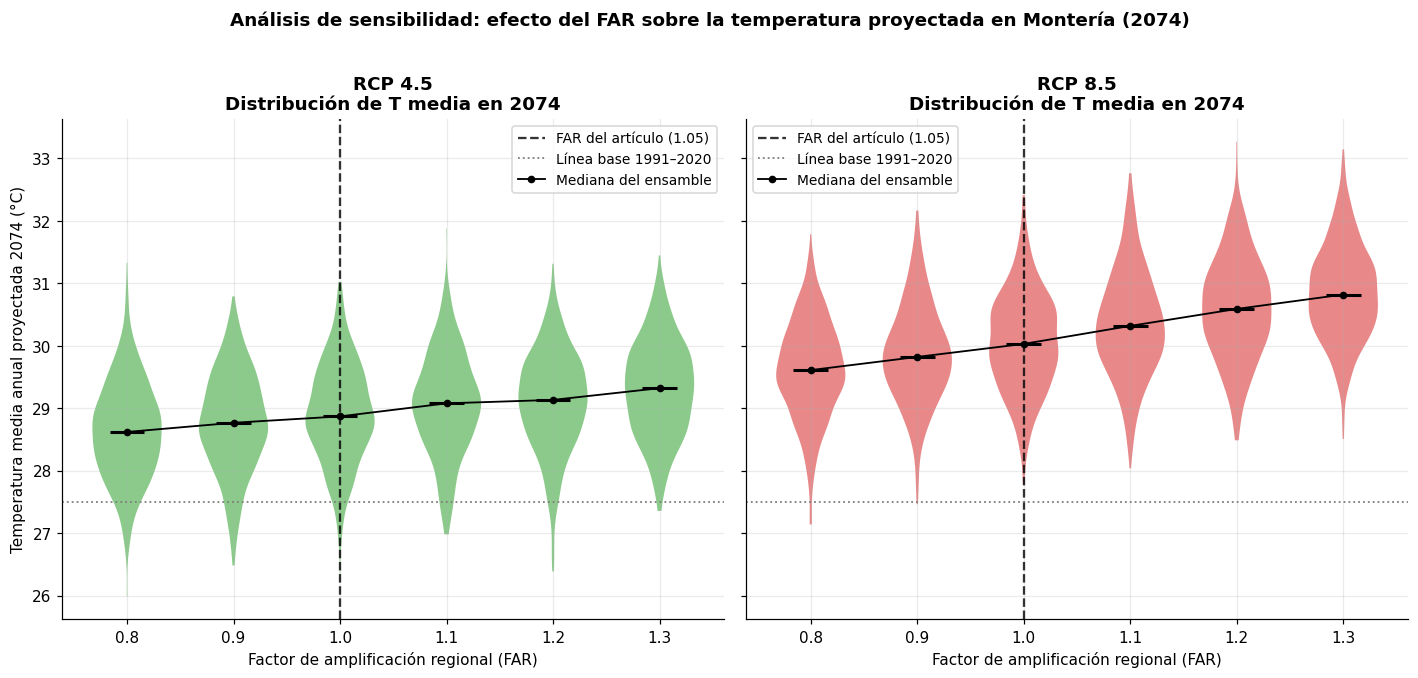


Rango de medianas según FAR (temperatura 2074):
  RCP 4.5: 28.62 – 29.32 °C (rango = 0.70 °C)
  RCP 8.5: 29.61 – 30.82 °C (rango = 1.21 °C)


In [4]:
far_values = np.round(np.arange(0.80, 1.35, 0.10), 2)

# Para cada FAR (fijo, sin incertidumbre), calcular T en 2074 bajo cada RCP
results_far = {rcp: [] for rcp in RCP_LIST}
for far in far_values:
    for rcp in RCP_LIST:
        delta = df_anom.loc[anios_proy[0]:anios_proy[-1], f"RCP {rcp}"].values
        eps   = np.random.normal(0, SIGMA_INTERANUAL, (N_ENSAMBLE, n_anios))
        T2074 = (T_BASE_MON + far * delta[None, :] + eps)[:, -1]
        results_far[rcp].append(T2074)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, rcp in zip(axes, ['4.5', '8.5']):
    positions = np.arange(len(far_values))
    vp = ax.violinplot(results_far[rcp], positions=positions,
                       showmedians=True, showextrema=False, widths=0.65)
    for body in vp['bodies']:
        body.set_facecolor(RCP_COLORS[rcp])
        body.set_alpha(0.55)
    vp['cmedians'].set_color('black')
    vp['cmedians'].set_linewidth(2)

    # Resaltar el FAR usado en el artículo
    actual_idx = np.argmin(np.abs(far_values - FAR_NSA))
    ax.axvline(actual_idx, color='black', ls='--', lw=1.5, alpha=0.8,
               label=f'FAR del artículo ({FAR_NSA})')
    ax.axhline(T_BASE_MON, color='gray', ls=':', lw=1.2, label='Línea base 1991–2020')

    # Mediana por FAR
    medianas = [np.median(d) for d in results_far[rcp]]
    ax.plot(positions, medianas, 'ko-', ms=4, lw=1.2, zorder=5, label='Mediana del ensamble')

    ax.set_xticks(positions)
    ax.set_xticklabels([str(f) for f in far_values])
    ax.set_xlabel('Factor de amplificación regional (FAR)')
    ax.set_title(f'RCP {rcp}\nDistribución de T media en 2074', fontweight='bold')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Temperatura media anual proyectada 2074 (°C)')
fig.suptitle('Análisis de sensibilidad: efecto del FAR sobre la temperatura proyectada en Montería (2074)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_B_sensibilidad_far.png', bbox_inches='tight')
plt.show()

# Tabla de rangos
print("\nRango de medianas según FAR (temperatura 2074):")
for rcp in ['4.5', '8.5']:
    medianas = [np.median(d) for d in results_far[rcp]]
    print(f"  RCP {rcp}: {min(medianas):.2f} – {max(medianas):.2f} °C "
          f"(rango = {max(medianas)-min(medianas):.2f} °C)")

**Lectura:** la incertidumbre en el FAR introduce un rango de ~0.5–0.7 °C en la temperatura mediana proyectada para 2074, comparable en magnitud a la diferencia entre escenarios adyacentes (RCP 2.6 vs RCP 4.5). Esto subraya la importancia de contar con estudios de regionalización climática de alta resolución para el Caribe colombiano que acoten mejor este parámetro, y justifica el enfoque probabilístico adoptado en el artículo principal.

## Análisis 3: Tiempo de emergencia del calentamiento

El **tiempo de emergencia** (*Time of Emergence*, ToE) es el año a partir del cual la señal de calentamiento supera de manera sostenida el umbral de la variabilidad climática natural. Es un indicador clave para la planificación de la adaptación: determina desde cuándo el clima de Montería será consistentemente diferente al que se conoció en la segunda mitad del siglo XX.

Se define:
- **ToE débil (1σ):** señal/ruido > 1 durante ≥ 5 años consecutivos  
- **ToE robusto (2σ):** señal/ruido > 2 durante ≥ 5 años consecutivos  

donde la señal es la anomalía de la temperatura media del ensamble respecto a la línea base, y el ruido es la desviación estándar interanual de la variabilidad natural (σ = 0.8 °C).

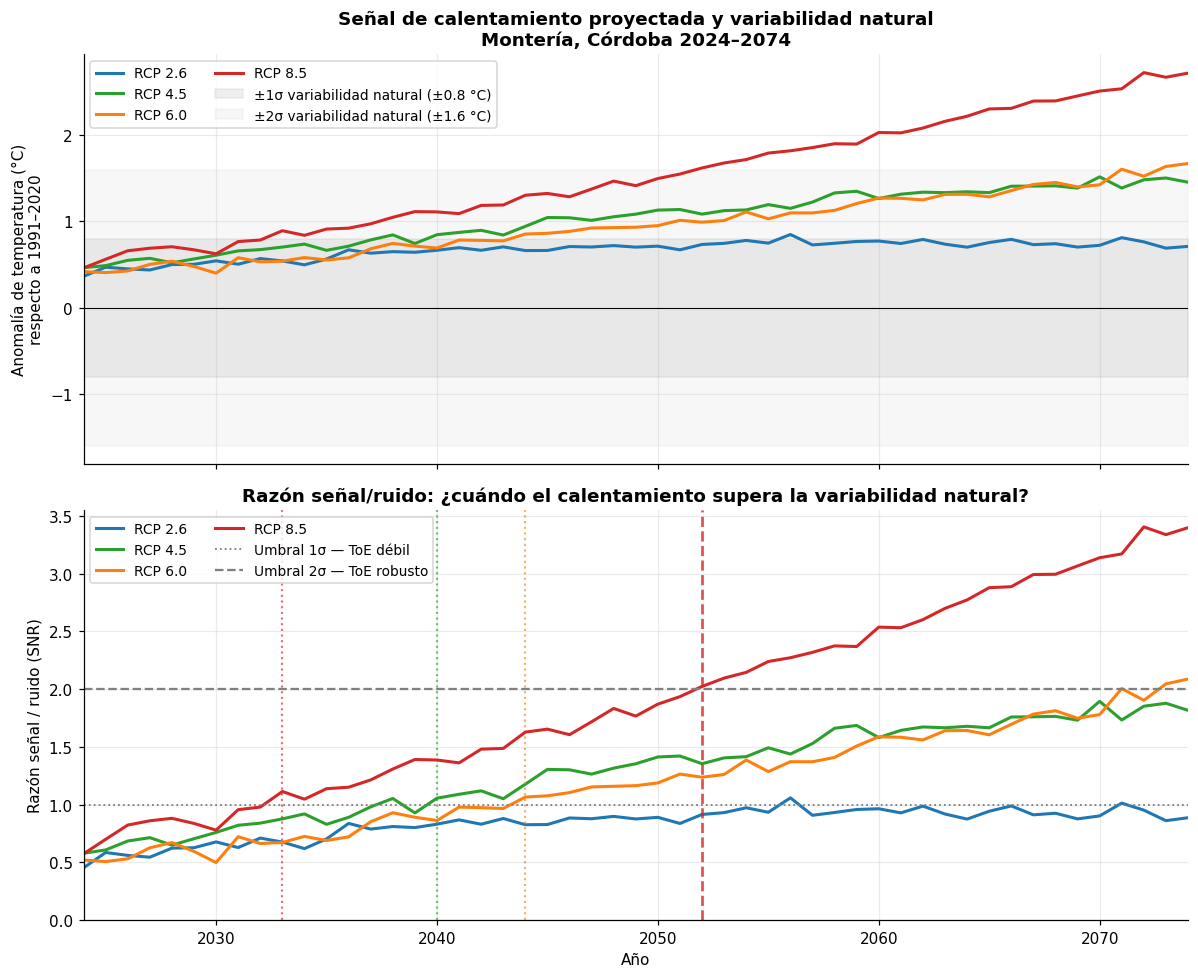


Tabla de tiempos de emergencia por escenario:


,Escenario,ToE débil (1σ),ToE robusto (2σ),SNR en 2074
0,RCP 2.6,>2074,>2074,0.89
1,RCP 4.5,2040,>2074,1.82
2,RCP 6.0,2044,>2074,2.09
3,RCP 8.5,2033,2052,3.40


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

toe_records = []

for rcp in RCP_LIST:
    mat    = proyecciones[rcp]
    signal = mat.mean(axis=0) - T_BASE_MON   # anomalía media del ensamble
    snr    = signal / SIGMA_INTERANUAL         # razón señal/ruido

    toe_1s = toe_2s = None
    for i in range(len(anios_proy) - 4):
        if toe_1s is None and np.all(snr[i:i+5] > 1.0):
            toe_1s = anios_proy[i]
        if toe_2s is None and np.all(snr[i:i+5] > 2.0):
            toe_2s = anios_proy[i]

    toe_records.append({
        'Escenario': f'RCP {rcp}',
        'ToE débil (1σ)':   int(toe_1s) if toe_1s else '>2074',
        'ToE robusto (2σ)': int(toe_2s) if toe_2s else '>2074',
        'SNR en 2074': f'{snr[-1]:.2f}',
    })

    color = RCP_COLORS[rcp]
    ax1.plot(anios_proy, signal, color=color, lw=2, label=f'RCP {rcp}')
    ax2.plot(anios_proy, snr,    color=color, lw=2, label=f'RCP {rcp}')

    if toe_1s:
        ax2.axvline(toe_1s, color=color, ls=':', lw=1.4, alpha=0.65)
    if toe_2s:
        ax2.axvline(toe_2s, color=color, ls='--', lw=1.8, alpha=0.8)

# Bandas de variabilidad natural
ax1.fill_between(anios_proy, -SIGMA_INTERANUAL, SIGMA_INTERANUAL,
                 alpha=0.12, color='gray', label=f'±1σ variabilidad natural (±{SIGMA_INTERANUAL} °C)')
ax1.fill_between(anios_proy, -2*SIGMA_INTERANUAL, 2*SIGMA_INTERANUAL,
                 alpha=0.06, color='gray', label=f'±2σ variabilidad natural (±{2*SIGMA_INTERANUAL} °C)')
ax1.axhline(0, color='black', lw=0.7)
ax1.set_ylabel('Anomalía de temperatura (°C)\nrespecto a 1991–2020')
ax1.set_title('Señal de calentamiento proyectada y variabilidad natural\nMontería, Córdoba 2024–2074',
              fontweight='bold')
ax1.legend(fontsize=9, ncol=2, loc='upper left')

ax2.axhline(1, color='gray', ls=':',  lw=1.2, label='Umbral 1σ — ToE débil')
ax2.axhline(2, color='gray', ls='--', lw=1.5, label='Umbral 2σ — ToE robusto')
ax2.set_ylabel('Razón señal / ruido (SNR)')
ax2.set_xlabel('Año')
ax2.set_title('Razón señal/ruido: ¿cuándo el calentamiento supera la variabilidad natural?',
              fontweight='bold')
ax2.legend(fontsize=9, ncol=2, loc='upper left')
ax2.set_xlim(ANIO_INICIO, ANIO_FIN)
ax2.set_ylim(0, None)

plt.tight_layout()
plt.savefig('fig_C_tiempo_emergencia.png', bbox_inches='tight')
plt.show()

df_toe = pd.DataFrame(toe_records)
print("\nTabla de tiempos de emergencia por escenario:")
df_toe

**Lectura:** bajo los escenarios de altas emisiones (RCP 6.0 y 8.5), el calentamiento en Montería emerge robustamente (2σ) antes de mediados del periodo analizado, lo que significa que para entonces los tomadores de decisiones ya enfrentarán condiciones térmicas estadísticamente distinguibles del pasado reciente. En contraste, bajo RCP 2.6, la emergencia robusta del calentamiento podría retrasarse más allá de 2074, subrayando el valor de la mitigación de emisiones como estrategia para ganar tiempo de adaptación.